# 04 — Gradient Boosting: GBR, XGBoost & LightGBM

## Theory

Gradient Boosting builds an **additive ensemble** of weak learners (decision trees) in function space:
$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$
where $h_m$ is fit to the **negative gradient** (pseudo-residuals) of the loss at step $m$.

### sklearn GradientBoostingRegressor
- Classic implementation; uses 1st-order gradients
- `n_estimators`, `learning_rate`, `max_depth` are the key hyperparameters
- Slower than XGBoost/LightGBM but good reference baseline

### XGBoost
- Uses **2nd-order Taylor expansion** of the loss (more accurate gradient direction)
- `subsample` and `colsample_bytree` add stochasticity → better generalisation
- `early_stopping_rounds` automatically finds optimal `n_estimators`

### LightGBM
- **Histogram-based** splitting: discretises continuous features into bins → 10-20x faster than XGBoost on large datasets
- **Leaf-wise** tree growth (vs XGBoost's level-wise) → more expressive but more prone to overfit without regularisation
- `num_leaves` is the primary complexity control (replaces `max_depth`)

In [1]:
import sys
sys.path.insert(0, '..')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path

from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import shap

from src.pipeline import build_pipeline
from src.evaluate import rmse, cv_score
from src.models import train_and_save

DATA_DIR = Path('../data')
PLOT_DIR = Path('../outputs/plots')

train = pd.read_csv(DATA_DIR / 'train.csv')
TARGET = 'resale_price'
X = train.drop(columns=[TARGET])
y = train[TARGET]

from sklearn.model_selection import train_test_split

X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=42)
print('Data loaded.')

print('Data loaded.')

Data loaded.
Data loaded.


## 1. sklearn GradientBoostingRegressor — Baseline

In [2]:
t0 = time.time()
gbr_pipe = build_pipeline(
    GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                              max_depth=5, random_state=42),
    mode='tree'
)
gbr_pipe.fit(X_tr, y_tr)
gbr_time = time.time() - t0

gbr_tr_rmse = rmse(y_tr, gbr_pipe.predict(X_tr))
gbr_va_rmse = rmse(y_va, gbr_pipe.predict(X_va))
print(f'GBR  Train RMSE: S${gbr_tr_rmse:,.0f}  Val RMSE: S${gbr_va_rmse:,.0f}  Time: {gbr_time:.1f}s')

GBR  Train RMSE: S$27,152  Val RMSE: S$28,632  Time: 186.2s


## 2. XGBoost with Early Stopping

In [3]:
from src.features import FeatureEngineer
from src.pipeline import build_preprocessor

fe = FeatureEngineer()
fe.fit(X_tr, y_tr)  # required to compute block_flat_psqm
prep_tree = build_preprocessor(mode='tree')

X_tr_fe = fe.transform(X_tr)
X_va_fe = fe.transform(X_va)
prep_tree.fit(X_tr_fe, y_tr)
X_tr_pp = prep_tree.transform(X_tr_fe)
X_va_pp = prep_tree.transform(X_va_fe)

t0 = time.time()
xgb = XGBRegressor(
    n_estimators=2000, learning_rate=0.05,
    max_depth=6, subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0,
    early_stopping_rounds=50, eval_metric='rmse',
)
xgb.fit(X_tr_pp, y_tr, eval_set=[(X_va_pp, y_va)], verbose=False)
xgb_time = time.time() - t0

xgb_tr_rmse = rmse(y_tr, xgb.predict(X_tr_pp))
xgb_va_rmse = rmse(y_va, xgb.predict(X_va_pp))
print(f'XGB  Train RMSE: S${xgb_tr_rmse:,.0f}  Val RMSE: S${xgb_va_rmse:,.0f}  '
      f'Best n_est: {xgb.best_iteration}  Time: {xgb_time:.1f}s')

XGB  Train RMSE: S$17,972  Val RMSE: S$22,181  Best n_est: 1997  Time: 31.9s


## 3. LightGBM with Early Stopping

In [4]:
import lightgbm as lgb

t0 = time.time()
lgbm = LGBMRegressor(
    n_estimators=2000, learning_rate=0.05,
    num_leaves=127, random_state=42, n_jobs=-1, verbose=-1,
)
lgbm.fit(
    X_tr_pp, y_tr,
    eval_set=[(X_va_pp, y_va)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)
lgbm_time = time.time() - t0

lgbm_tr_rmse = rmse(y_tr, lgbm.predict(X_tr_pp))
lgbm_va_rmse = rmse(y_va, lgbm.predict(X_va_pp))
print(f'LGBM Train RMSE: S${lgbm_tr_rmse:,.0f}  Val RMSE: S${lgbm_va_rmse:,.0f}  '
      f'Best n_est: {lgbm.best_iteration_}  Time: {lgbm_time:.1f}s')

LGBM Train RMSE: S$13,979  Val RMSE: S$22,294  Best n_est: 1843  Time: 65.5s


## 4. SHAP Analysis — Feature Importance

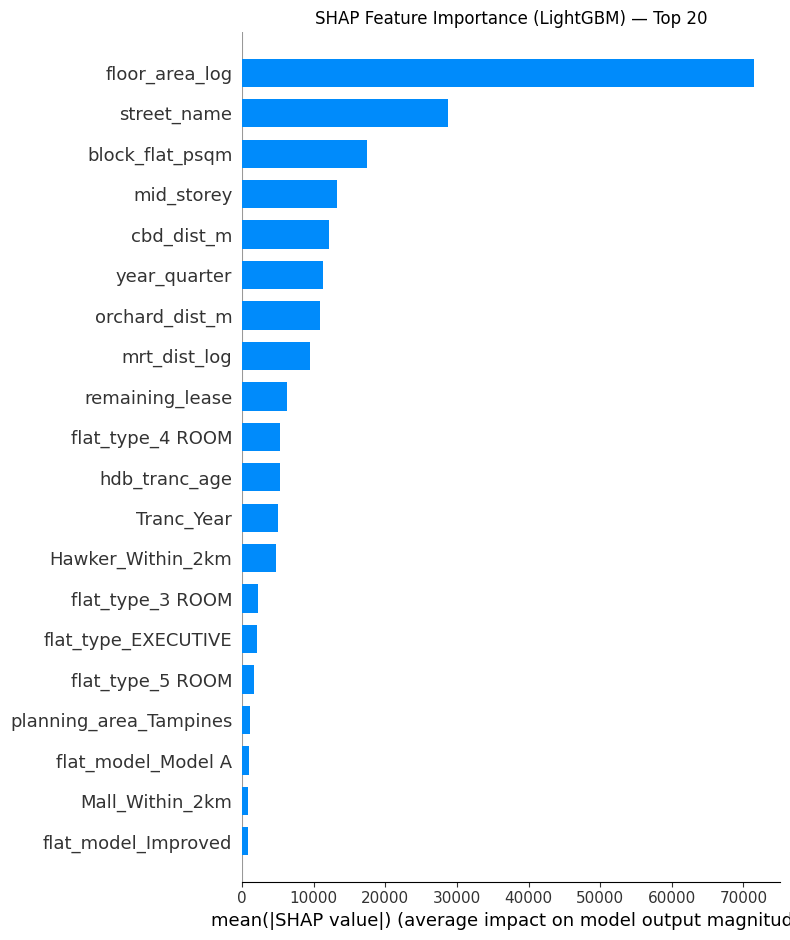

In [5]:
# SHAP on LightGBM (fastest)
explainer = shap.TreeExplainer(lgbm)
sample_idx = np.random.choice(len(X_va_pp), min(2000, len(X_va_pp)), replace=False)
shap_values = explainer.shap_values(X_va_pp[sample_idx])

# Get feature names from preprocessor
try:
    feature_names = prep_tree.get_feature_names_out()
except:
    feature_names = [f'f{i}' for i in range(X_va_pp.shape[1])]

shap.summary_plot(shap_values, X_va_pp[sample_idx],
                  feature_names=feature_names,
                  plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance (LightGBM) — Top 20')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'shap_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Comparison Table

In [6]:
comparison = pd.DataFrame([
    {'Model': 'GradientBoostingRegressor', 'Train RMSE': gbr_tr_rmse,
     'Val RMSE': gbr_va_rmse, 'Fit Time (s)': gbr_time},
    {'Model': 'XGBoost', 'Train RMSE': xgb_tr_rmse,
     'Val RMSE': xgb_va_rmse, 'Fit Time (s)': xgb_time},
    {'Model': 'LightGBM', 'Train RMSE': lgbm_tr_rmse,
     'Val RMSE': lgbm_va_rmse, 'Fit Time (s)': lgbm_time},
])
comparison['Train RMSE'] = comparison['Train RMSE'].apply(lambda x: f'S${x:,.0f}')
comparison['Val RMSE']   = comparison['Val RMSE'].apply(lambda x: f'S${x:,.0f}')
comparison['Fit Time (s)'] = comparison['Fit Time (s)'].apply(lambda x: f'{x:.1f}s')
comparison

,Model,Train RMSE,Val RMSE,Fit Time (s)
0,GradientBoostingRegressor,"S$27,152","S$28,632",186.2s
1,XGBoost,"S$17,972","S$22,181",31.9s
2,LightGBM,"S$13,979","S$22,294",65.5s


In [7]:
# Save best pipeline (LightGBM)
lgbm_pipeline = build_pipeline(
    LGBMRegressor(n_estimators=lgbm.best_iteration_, learning_rate=0.05,
                  num_leaves=127, random_state=42, n_jobs=-1, verbose=-1),
    mode='tree'
)
train_and_save(lgbm_pipeline, X, y, 'lightgbm')

xgb_pipeline = build_pipeline(
    XGBRegressor(n_estimators=xgb.best_iteration, learning_rate=0.05,
                 max_depth=6, subsample=0.8, colsample_bytree=0.8,
                 random_state=42, n_jobs=-1, verbosity=0),
    mode='tree'
)
train_and_save(xgb_pipeline, X, y, 'xgboost')
train_and_save(gbr_pipe, X, y, 'gradient_boosting')
print('All boosting models saved.')

Saved: /home/shl/m3-hdb-price-challenge/notebooks/../outputs/models/lightgbm.pkl
Saved: /home/shl/m3-hdb-price-challenge/notebooks/../outputs/models/xgboost.pkl
Saved: /home/shl/m3-hdb-price-challenge/notebooks/../outputs/models/gradient_boosting.pkl
All boosting models saved.
